In [52]:
import pandas as pd
import numpy as np
import gspread

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import LinearRegression
from google.oauth2.service_account import Credentials

In [ ]:
'''
# Read data from gsheet

SERVICE_ACCOUNT_FILE = '../../key/credentials.json'
SCOPES = ['https://www.googleapis.com/auth/spreadsheets',
          'https://www.googleapis.com/auth/drive']

creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
client = gspread.authorize(creds)

sheet = client.open('[4] AI QC Inbound CRM Review 语音智能质检打标复审').worksheet('New 5')
data = sheet.get_all_records()

df = pd.DataFrame(data[0:], columns=data[0])
df.to_csv('../../raw_data/new_hotline_4.csv', index=False)
'''

In [54]:
df

,No,Tanggal Pengerjaan,Checker,ASI/AFI,Waktu Inbound,Nomor Inbound,Nama Agent,Call ID,Durasi Bicara,Detik,...,Status,Sampling user side,Hasil Pemeriksaan Kualitas (old),Hasil ASR,Hasil Pemeriksaan Kualitas,Efektif,Kejelasan Suara,Suara Lain,Kelengkapan Rekaman,Agent Sampling
0,1,03/16/2026,Neneng,ASI,2026-03-15 20:00:46,0878****0038,Isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:32,...,,Done,,,Percakapan Normal,Miss Target/ Not HC,"Sangat jelas, tidak bising sama sekali",0 Satu pembicara,0 Utuh,
1,2,03/16/2026,Neneng,ASI,2026-03-15 20:00:46,0878****0038,Isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:40,...,,Done,,,Percakapan Normal,Miss Target/ Not HC,"Sangat jelas, tidak bising sama sekali",0 Satu pembicara,0 Utuh,
2,3,03/16/2026,Neneng,ASI,2026-03-15 20:00:46,0878****0038,Isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:47,...,,Done,,,Percakapan Normal,Miss Target/ Not HC,Cukup Jelas,0 Satu pembicara,0 Utuh,
3,4,03/16/2026,Neneng,ASI,2026-03-15 20:00:46,0878****0038,Isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:50,...,,Done,,,Percakapan Normal,Miss Target/ Not HC,Cukup Jelas,0 Satu pembicara,0 Utuh,
4,5,03/16/2026,Neneng,ASI,2026-03-15 20:00:46,0878****0038,Isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:52,...,,Done,,,Percakapan Normal,Miss Target/ Not HC,Cukup Jelas,0 Satu pembicara,0 Utuh,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15296,14872,04/14/2026,Azer,ASI,2026-04-09 23:12:03,0818****3738,SMHL_Dalyadi,9b70a702067e45498e8a2679b712920e,0:09:19,2026-04-09 23:20:27,...,,Done,,,,,,,,
15297,14873,04/14/2026,Azer,ASI,2026-04-09 23:12:03,0818****3738,SMHL_Dalyadi,9b70a702067e45498e8a2679b712920e,0:09:19,2026-04-09 23:20:28,...,,Done,,,,,,,,
15298,14874,04/14/2026,Azer,ASI,2026-04-09 23:12:03,0818****3738,SMHL_Dalyadi,9b70a702067e45498e8a2679b712920e,0:09:19,2026-04-09 23:20:41,...,,Done,,,,,,,,
15299,14875,04/14/2026,Azer,ASI,2026-04-09 23:12:03,0818****3738,SMHL_Dalyadi,9b70a702067e45498e8a2679b712920e,0:09:19,2026-04-09 23:20:52,...,,Done,,,,,,,,


In [55]:
# Lowering all data and removing extra spaces
df_clean = (
    df.copy()
    .drop(columns=['No'])
    .apply(lambda x: x.str.lower() if x.dtype == 'object' else x)
    .apply(lambda x: x.str.strip() if x.dtype == 'object' else x)
)

# lowering all columns names and removing extra spaces
df_clean.columns = (
    df_clean
    .columns.str.lower().str.strip()
    .str.replace(' ', '_')
)

# excluding today date
today = df_clean['tanggal_pengerjaan'].max()
df_clean = df_clean[df_clean['tanggal_pengerjaan'] < today]

# data types
df_clean['tanggal_pengerjaan'] = pd.to_datetime(df_clean['tanggal_pengerjaan'], errors='coerce')

df_clean

,tanggal_pengerjaan,checker,asi/afi,waktu_inbound,nomor_inbound,nama_agent,call_id,durasi_bicara,detik,total_tiket_riskan,...,status,sampling_user_side,hasil_pemeriksaan_kualitas_(old),hasil_asr,hasil_pemeriksaan_kualitas,efektif,kejelasan_suara,suara_lain,kelengkapan_rekaman,agent_sampling
0,2026-03-16,neneng,asi,2026-03-15 20:00:46,0878****0038,isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:32,,...,,done,,,percakapan normal,miss target/ not hc,"sangat jelas, tidak bising sama sekali",0 satu pembicara,0 utuh,
1,2026-03-16,neneng,asi,2026-03-15 20:00:46,0878****0038,isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:40,,...,,done,,,percakapan normal,miss target/ not hc,"sangat jelas, tidak bising sama sekali",0 satu pembicara,0 utuh,
2,2026-03-16,neneng,asi,2026-03-15 20:00:46,0878****0038,isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:47,,...,,done,,,percakapan normal,miss target/ not hc,cukup jelas,0 satu pembicara,0 utuh,
3,2026-03-16,neneng,asi,2026-03-15 20:00:46,0878****0038,isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:50,,...,,done,,,percakapan normal,miss target/ not hc,cukup jelas,0 satu pembicara,0 utuh,
4,2026-03-16,neneng,asi,2026-03-15 20:00:46,0878****0038,isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:52,,...,,done,,,percakapan normal,miss target/ not hc,cukup jelas,0 satu pembicara,0 utuh,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15090,2026-04-13,neneng,asi,2026-04-07 15:13:04,0859****8481,tchl_afifuddin reza arifani,a3256dd7fda24300ace26fdc3c7ecfbc,0:08:17,2026-04-07 15:19:44,,...,,done,,,percakapan normal,miss target/ not hc,cukup jelas,0 satu pembicara,0 utuh,
15091,2026-04-13,neneng,asi,2026-04-07 15:13:04,0859****8481,tchl_afifuddin reza arifani,a3256dd7fda24300ace26fdc3c7ecfbc,0:08:17,2026-04-07 15:19:49,,...,,done,,,percakapan normal,miss target/ not hc,"sangat jelas, tidak bising sama sekali",0 satu pembicara,0 utuh,
15092,2026-04-13,neneng,asi,2026-04-07 15:13:04,0859****8481,tchl_afifuddin reza arifani,a3256dd7fda24300ace26fdc3c7ecfbc,0:08:17,2026-04-07 15:19:51,,...,,done,,,percakapan normal & aturan lainnya,miss target/ not hc,"sangat jelas, tidak bising sama sekali",0 satu pembicara,0 utuh,
15093,2026-04-13,neneng,asi,2026-04-07 15:13:04,0859****8481,tchl_afifuddin reza arifani,a3256dd7fda24300ace26fdc3c7ecfbc,0:08:17,2026-04-07 15:19:56,,...,,done,,,percakapan normal,miss target/ not hc,cukup jelas,0 satu pembicara,0 utuh,


In [56]:
# rata-rata pengerjaan per hari
count = df_clean['tanggal_pengerjaan'].value_counts().sort_index()
count

tanggal_pengerjaan
2026-03-16     336
2026-03-17     370
2026-03-25     642
2026-03-26     912
2026-03-27     965
2026-03-30     907
2026-03-31     975
2026-04-01    1254
2026-04-02     963
2026-04-06    1373
2026-04-07    1382
2026-04-08    1425
2026-04-09    1417
2026-04-10    1043
2026-04-13    1131
Name: count, dtype: int64

In [57]:
count = pd.DataFrame(count)
round(count['count'].mean())

1006

In [58]:
# cumulative sum for total data

df_clean.groupby('tanggal_pengerjaan')['call_id'].size().sort_index().cumsum()

tanggal_pengerjaan
2026-03-16      336
2026-03-17      706
2026-03-25     1348
2026-03-26     2260
2026-03-27     3225
2026-03-30     4132
2026-03-31     5107
2026-04-01     6361
2026-04-02     7324
2026-04-06     8697
2026-04-07    10079
2026-04-08    11504
2026-04-09    12921
2026-04-10    13964
2026-04-13    15095
Name: call_id, dtype: int64

In [59]:
df_clean[df_clean['asi/afi'] == 'afi'].groupby('tanggal_pengerjaan')['call_id'].size().sort_index().cumsum()

tanggal_pengerjaan
2026-03-26     411
2026-03-27     660
2026-03-31     751
2026-04-01    1065
2026-04-02    1096
2026-04-06    1634
2026-04-07    2030
2026-04-08    2447
Name: call_id, dtype: int64

In [60]:
# cumulative sum for unique call_id
cum_call_id = df_clean.groupby('tanggal_pengerjaan')['call_id'].nunique().sort_index().cumsum()
cum_call_id

tanggal_pengerjaan
2026-03-16      5
2026-03-17     10
2026-03-25     15
2026-03-26     24
2026-03-27     34
2026-03-30     43
2026-03-31     53
2026-04-01     68
2026-04-02     75
2026-04-06     90
2026-04-07    108
2026-04-08    121
2026-04-09    132
2026-04-10    142
2026-04-13    156
Name: call_id, dtype: int64

In [61]:
df_clean[df_clean['asi/afi'] == 'afi'].groupby('tanggal_pengerjaan')['call_id'].nunique().sort_index().cumsum()

tanggal_pengerjaan
2026-03-26     4
2026-03-27     7
2026-03-31     8
2026-04-01    10
2026-04-02    11
2026-04-06    18
2026-04-07    24
2026-04-08    31
Name: call_id, dtype: int64

### Visualization

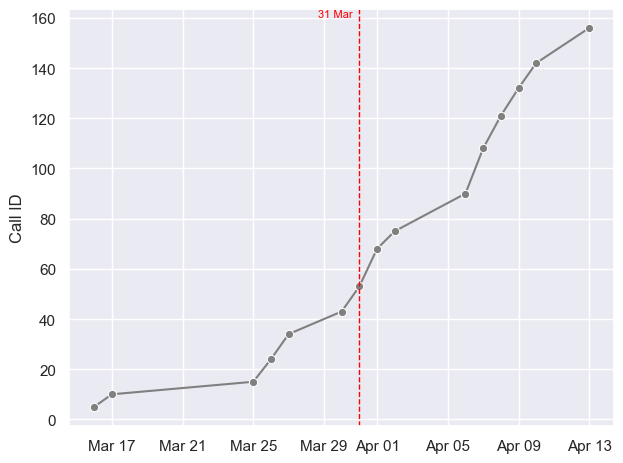

In [62]:
cum_call_id_viz = pd.DataFrame(cum_call_id.reset_index())

sns.set_theme(style='darkgrid')
ax = sns.lineplot(
    data=cum_call_id_viz,
    x='tanggal_pengerjaan',
    y='call_id',
    marker='o',
    color='grey'
)

ax.axvline(pd.to_datetime('2026-03-31'), color='red', linestyle='--', linewidth=1)
ax.text(pd.to_datetime('2026-03-31'), ax.get_ylim()[1], '31 Mar  ', 
        color='red', ha='right', va='top', fontsize=8)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_xlabel('')
ax.set_ylabel('Call ID')

plt.tight_layout()
plt.show()

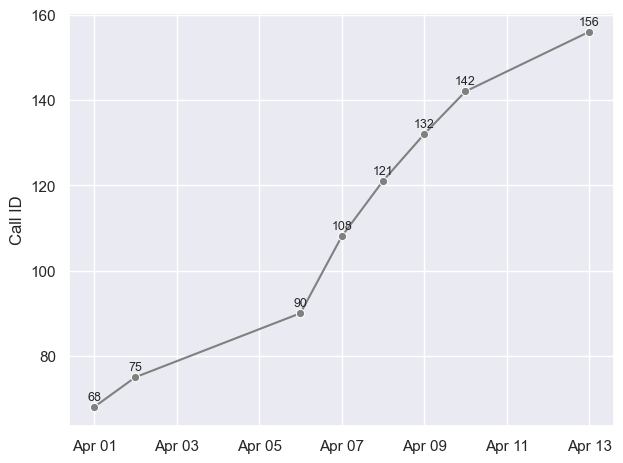

In [63]:
count_april = cum_call_id_viz[cum_call_id_viz['tanggal_pengerjaan'].dt.month == 4]
count_april = pd.DataFrame(count_april)

ax = sns.lineplot(
    data=count_april,
    x='tanggal_pengerjaan',
    y='call_id',
    marker='o',
    color='grey'
)

for x, y in zip(count_april['tanggal_pengerjaan'], count_april['call_id']):
    ax.text(x, y + 0.9, str(y), ha='center', va='bottom', fontsize=9)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_xlabel('')
ax.set_ylabel('Call ID')

plt.tight_layout()
plt.show()

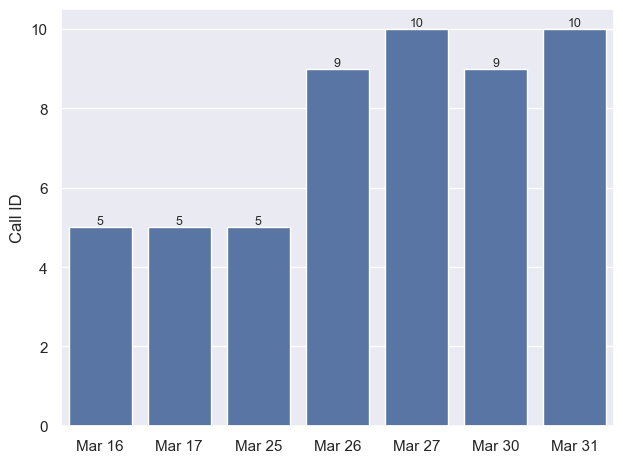

In [64]:
# hitung unique call_id per hari
daily_call_ids = (
    df_clean.groupby('tanggal_pengerjaan')['call_id']
    .nunique()
    .sort_index()
    .reset_index()
)

# filter setelah 31 Maret
daily_call_ids = daily_call_ids[daily_call_ids['tanggal_pengerjaan'] <= '2026-03-31']

# ubah tanggal menjadi label string agar barplot tidak salah membaca tanggal
daily_call_ids['tanggal_label'] = daily_call_ids['tanggal_pengerjaan'].dt.strftime('%b %d')

# plot
sns.set_theme(style='darkgrid')

ax = sns.barplot(
    data=daily_call_ids,
    x='tanggal_label',
    y='call_id',
    color='#4C72B0'
)

# label angka di atas bar
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

ax.set_xlabel('')
ax.set_ylabel('Call ID')

plt.tight_layout()
plt.show()

## Prediction Model

Tanggal diprediksi mencapai 300 call_id:
2026-04-27 00:00:00


c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\

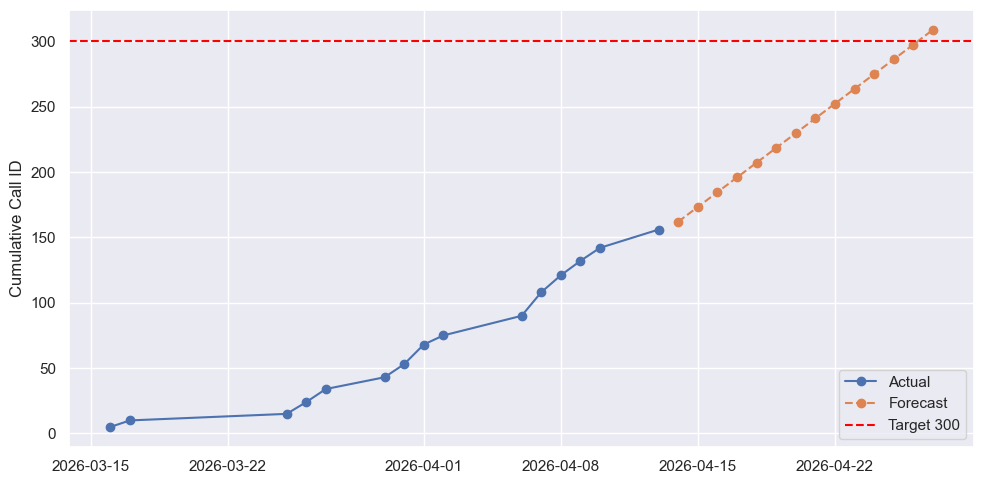

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

# =========================
# 1. Daily unique call_id
# =========================
daily_calls = (
    df_clean.groupby('tanggal_pengerjaan')['call_id']
    .nunique()
    .sort_index()
    .reset_index()
)

daily_calls['tanggal_pengerjaan'] = pd.to_datetime(daily_calls['tanggal_pengerjaan'])

# =========================
# 2. Cumulative sum
# =========================
daily_calls['cum_call_id'] = daily_calls['call_id'].cumsum()

# =========================
# 3. Feature time index
# =========================
daily_calls['t'] = np.arange(len(daily_calls))

X = daily_calls[['t']]
y = daily_calls['cum_call_id']

# =========================
# 4. Train model
# =========================
model = LinearRegression()
model.fit(X, y)

# =========================
# 5. Forecast until 300
# =========================
future_rows = []
t = daily_calls['t'].iloc[-1]

cum_pred = daily_calls['cum_call_id'].iloc[-1]
date = daily_calls['tanggal_pengerjaan'].iloc[-1]

while cum_pred < 300:
    
    t += 1
    date += pd.Timedelta(days=1)
    
    cum_pred = model.predict([[t]])[0]
    
    future_rows.append({
        'tanggal_pengerjaan': date,
        't': t,
        'cum_call_id_pred': cum_pred
    })

future_df = pd.DataFrame(future_rows)

print("Tanggal diprediksi mencapai 300 call_id:")
print(future_df[future_df['cum_call_id_pred'] >= 300].iloc[0]['tanggal_pengerjaan'])

# =========================
# 6. Plot hasil
# =========================
sns.set_theme(style='darkgrid')

plt.figure(figsize=(10,5))

plt.plot(
    daily_calls['tanggal_pengerjaan'],
    daily_calls['cum_call_id'],
    marker='o',
    label='Actual'
)

plt.plot(
    future_df['tanggal_pengerjaan'],
    future_df['cum_call_id_pred'],
    linestyle='--',
    marker='o',
    label='Forecast'
)

plt.axhline(300, color='red', linestyle='--', label='Target 300')

plt.xlabel('')
plt.ylabel('Cumulative Call ID')
plt.legend()

plt.tight_layout()
plt.show()

In [66]:

# =========================
# 1. Daily unique call_id
# =========================
daily_calls = (
    df_clean.groupby('tanggal_pengerjaan')['call_id']
    .nunique()
    .sort_index()
    .reset_index()
)

daily_calls['tanggal_pengerjaan'] = pd.to_datetime(daily_calls['tanggal_pengerjaan'])

# =========================
# 2. Buat time index
# =========================
daily_calls['t'] = np.arange(len(daily_calls))

X = daily_calls[['t']]
y = daily_calls['call_id']

# =========================
# 3. Train model
# =========================
model = LinearRegression()
model.fit(X, y)

# =========================
# 4. Prediksi 14 hari ke depan
# =========================
future_days = 14
last_t = daily_calls['t'].iloc[-1]
last_date = daily_calls['tanggal_pengerjaan'].iloc[-1]

future_data = []

for i in range(1, future_days + 1):
    
    t_future = last_t + i
    date_future = last_date + pd.Timedelta(days=i)
    
    pred = model.predict([[t_future]])[0]
    
    future_data.append({
        "tanggal_pengerjaan": date_future,
        "predicted_call_id": round(pred)
    })

future_df = pd.DataFrame(future_data)

print(future_df)

   tanggal_pengerjaan  predicted_call_id
0          2026-04-14                 15
1          2026-04-15                 16
2          2026-04-16                 17
3          2026-04-17                 17
4          2026-04-18                 18
5          2026-04-19                 18
6          2026-04-20                 19
7          2026-04-21                 20
8          2026-04-22                 20
9          2026-04-23                 21
10         2026-04-24                 21
11         2026-04-25                 22
12         2026-04-26                 23
13         2026-04-27                 23


c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\

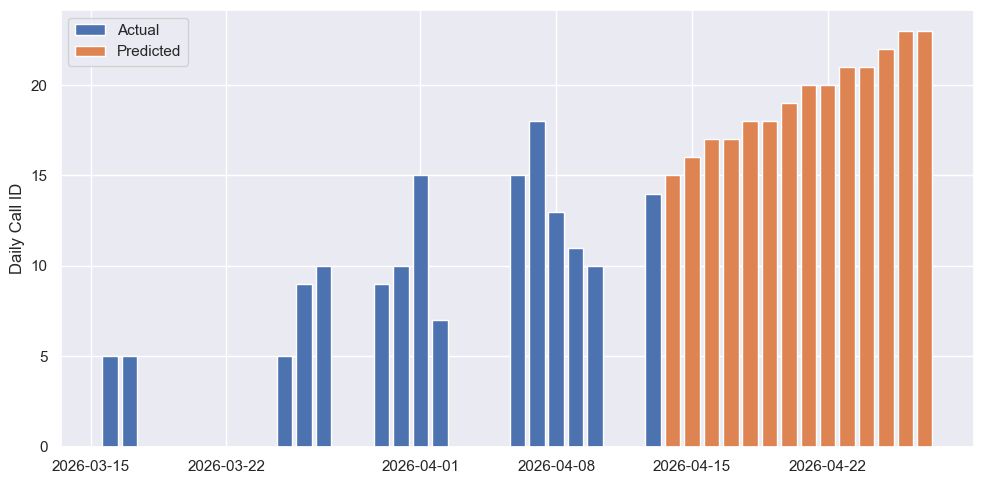

In [67]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(10,5))

plt.bar(
    daily_calls['tanggal_pengerjaan'],
    daily_calls['call_id'],
    # marker='o',
    label='Actual'
)

plt.bar(
    future_df['tanggal_pengerjaan'],
    future_df['predicted_call_id'],
    # marker='o',
    # linestyle='--',
    label='Predicted'
)

plt.xlabel('')
plt.ylabel('Daily Call ID')
plt.legend()

plt.tight_layout()
plt.show()

## 2nd Model

In [68]:
# daily unique call_id
daily_calls = (
    df_clean.groupby('tanggal_pengerjaan')['call_id']
    .nunique()
    .sort_index()
    .reset_index()
)

daily_calls['tanggal_pengerjaan'] = pd.to_datetime(daily_calls['tanggal_pengerjaan'])

# format untuk prophet
prophet_df = daily_calls.rename(columns={
    'tanggal_pengerjaan':'ds',
    'call_id':'y'
})

prophet_df.head()

,ds,y
0,2026-03-16,5
1,2026-03-17,5
2,2026-03-25,5
3,2026-03-26,9
4,2026-03-27,10


In [69]:
from prophet import Prophet

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

model.fit(prophet_df)

10:10:06 - cmdstanpy - INFO - Chain [1] start processing
10:10:07 - cmdstanpy - INFO - Chain [1] done processing


In [70]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
40,2026-05-09,24.039260,21.018719,26.980943
41,2026-05-10,24.416373,21.626919,27.214724
42,2026-05-11,25.932315,23.091434,28.702429
43,2026-05-12,27.728463,24.673919,30.611152
44,2026-05-13,26.843117,23.867931,29.793724


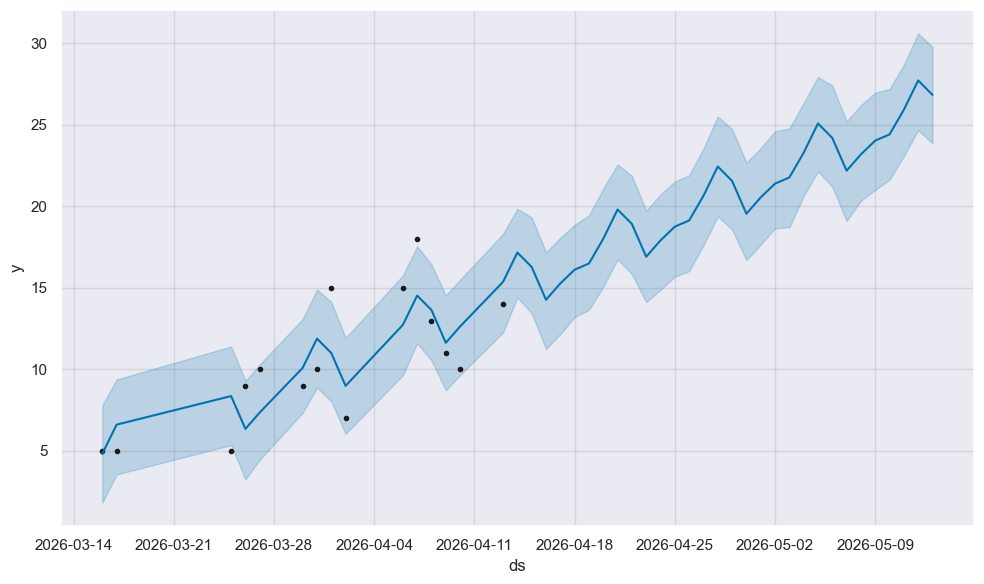

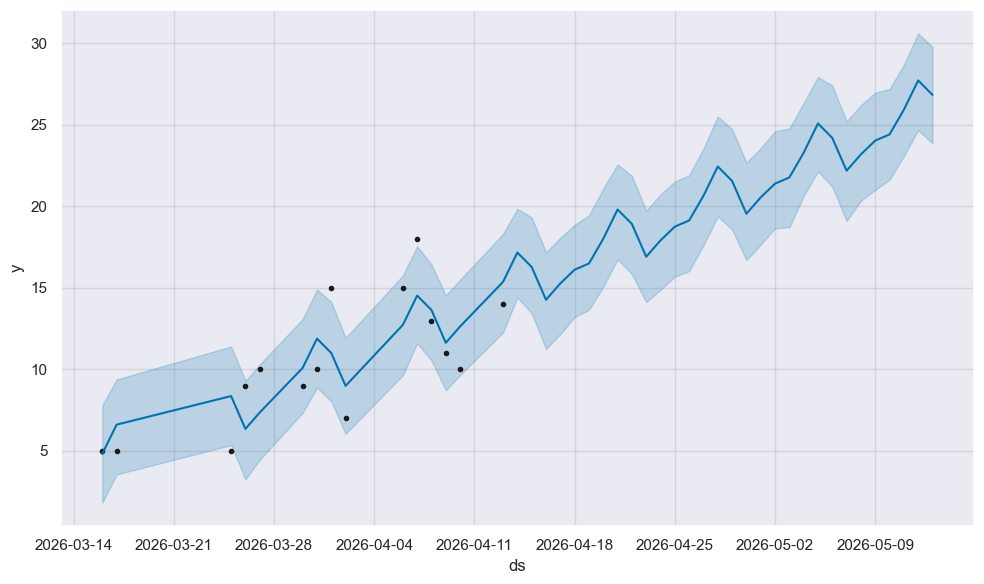

In [71]:
model.plot(forecast)

In [72]:
future_calls = forecast[['ds','yhat']].tail(30)

future_calls['yhat'] = future_calls['yhat'].round()

print(future_calls)

           ds  yhat
15 2026-04-14  17.0
16 2026-04-15  16.0
17 2026-04-16  14.0
18 2026-04-17  15.0
19 2026-04-18  16.0
20 2026-04-19  16.0
21 2026-04-20  18.0
22 2026-04-21  20.0
23 2026-04-22  19.0
24 2026-04-23  17.0
25 2026-04-24  18.0
26 2026-04-25  19.0
27 2026-04-26  19.0
28 2026-04-27  21.0
29 2026-04-28  22.0
30 2026-04-29  22.0
31 2026-04-30  20.0
32 2026-05-01  21.0
33 2026-05-02  21.0
34 2026-05-03  22.0
35 2026-05-04  23.0
36 2026-05-05  25.0
37 2026-05-06  24.0
38 2026-05-07  22.0
39 2026-05-08  23.0
40 2026-05-09  24.0
41 2026-05-10  24.0
42 2026-05-11  26.0
43 2026-05-12  28.0
44 2026-05-13  27.0


In [73]:
forecast['cum_pred'] = forecast['yhat'].cumsum()

target = forecast[forecast['cum_pred'] >= 300].iloc[0]

print("Prediksi mencapai 300 call pada:", target['ds'])

Prediksi mencapai 300 call pada: 2026-04-22 00:00:00


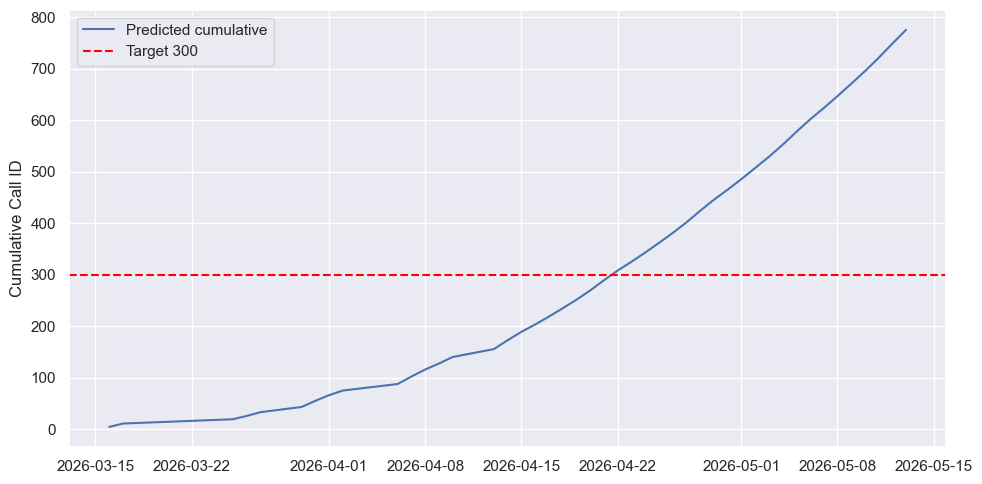

In [74]:
import matplotlib.pyplot as plt

forecast['cum_pred'] = forecast['yhat'].cumsum()

plt.figure(figsize=(10,5))

plt.plot(forecast['ds'], forecast['cum_pred'], label='Predicted cumulative')

plt.axhline(300, linestyle='--', color='red', label='Target 300')

plt.xlabel('')
plt.ylabel('Cumulative Call ID')

plt.legend()
plt.tight_layout()
plt.show()

## Prediction until 17 Apr

In [79]:
daily_calls

,tanggal_pengerjaan,call_id
0,2026-03-16,5
1,2026-03-17,5
2,2026-03-25,5
3,2026-03-26,9
4,2026-03-27,10
5,2026-03-30,9
6,2026-03-31,10
7,2026-04-01,15
8,2026-04-02,7
9,2026-04-06,15
